In [ ]:
'''Imports'''

import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc, mcscf
import numpy as np

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Hydrogen attack of Boron Nitrate

Using Active Space methods, construct a suitable active space for the hydrogen attack of boron nitrate system.

In this case, we will just plot an Hydrogen atom approaching a Boron Nitride molecule. 

This is just a minimal simulation of hydrogen ion attacking a boron nitride molecule. Ideally we would consider a sheet lattice of boron nitride with well defined perodicity. Then we would simulation this as mesh with hydrogen impurities.

Below is the Gif that illustrates the simulation

In [2]:
# ---------- BN + H+ approach ----------
def make_bn_h2_attack_gif(filename="../images/bn_h_attack.gif"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_xlim(-4.5, 2.2)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # BN fixed, H2 approaches B side
    x_B = 0.0
    x_N = 1.28
    h = 0.74
    h_start = -4.0
    h_end = -1.25
    h_positions = np.linspace(h_start, h_end, 60)
    
    points = ax.scatter([], [], s=500)
    labels = []
    bonds = []
    title = ax.text(-1.1, 0.95, "", ha="center", fontsize=13)
    
    def init():
        points.set_offsets(np.empty((0, 2)))
        return [points, title]
    
    def update(frame):
        nonlocal labels, bonds
        for t in labels:
            t.remove()
        for b in bonds:
            b.remove()
        labels = []
        bonds = []
        
        x_H1 = h_positions[frame]
        
        xs = np.array([x_B, x_N, x_H1])
        ys = np.array([0.0, 0.0, 0.0])
        points.set_offsets(np.c_[xs, ys])
        
        # BN bond
        bonds.append(ax.plot([x_B, x_N], [0, 0], lw=4)[0])
 
        # weak interaction / attack line when close
        if abs(x_H1 - x_B) < 2.0:
            bonds.append(ax.plot([x_H1, x_B], [0, 0], lw=2, linestyle="--")[0])
        
        for x, lab in zip(xs, ["B", "N", "H"]):
            labels.append(ax.text(x, -0.48, lab, ha="center", fontsize=12))
        
        title.set_text(r" Hydrogen attack of Boron Niride (H$+$ $\cdots$ BN)")
        return [points, title] + labels + bonds
    
    anim = FuncAnimation(fig, update, frames=len(h_positions), init_func=init, blit=True)
    anim.save(filename, writer=PillowWriter(fps=12))
    plt.close(fig)
    return filename

bn_h2_path = make_bn_h2_attack_gif()
bn_h2_path

'../images/bn_h_attack.gif'

## PySCF PES of H ... BN

In [3]:
def build_BNH_sim(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
    ncas=4,
    nelecas=(2, 2),
):
    """
    BN + H radical model.

    Total electrons:
    B = 5, N = 7, H = 1 -> 13 electrons.
    Open-shell doublet.

    ncas = 3 -> 6 qubits
    nelecas = (3, 2) -> 5 active electrons
    """

    mol = gto.Mole()
    mol.atom = f"""
    B   0.000000   0.000000   0.000000
    N   0.000000   0.000000   {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """
    mol.basis = basis
    mol.charge = 0
    mol.spin = 1       # doublet: N_alpha - N_beta = 1
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.ROHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas

converged SCF energy = -78.2406486045277
CASCI E = -78.3411977962350  E(CI) = -2.02797582476285  S^2 = 0.7500000
H distance = 3.00 Å | HF = -78.2406486045 | CASCI = -78.3411977962 | corr = -0.1005491917
converged SCF energy = -78.3123219210851
CASCI E = -78.3627145743058  E(CI) = -2.10132435685800  S^2 = 0.7500000
H distance = 2.50 Å | HF = -78.3123219211 | CASCI = -78.3627145743 | corr = -0.0503926532
converged SCF energy = -78.3136515971938
CASCI E = -78.4139717494519  E(CI) = -2.39253654227056  S^2 = 0.7500000
H distance = 2.00 Å | HF = -78.3136515972 | CASCI = -78.4139717495 | corr = -0.1003201523
converged SCF energy = -78.4813956023801
CASCI E = -78.4816207688453  E(CI) = -2.69690200052280  S^2 = 0.7500000
H distance = 1.70 Å | HF = -78.4813956024 | CASCI = -78.4816207688 | corr = -0.0002251665
converged SCF energy = -78.5353139591814
CASCI E = -78.5673612539642  E(CI) = -2.72738507943527  S^2 = 0.7500000
H distance = 1.50 Å | HF = -78.5353139592 | CASCI = -78.5673612540 | corr =

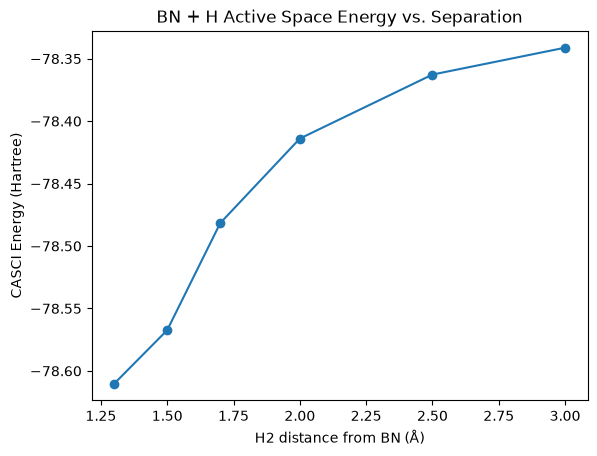

In [4]:
ecas_arr = []
for r in [3.0, 2.5, 2.0, 1.7, 1.5, 1.3]:
    mol, mf, mc, h1eff, ecore, eri_cas = build_BNH_sim(
        h_distance=r,
        ncas=3,
        nelecas=(2,1),
    )

    e_cas = mc.kernel()[0]
    ecas_arr.append(e_cas)

    print(
        f"H distance = {r:4.2f} Å | "
        f"HF = {mf.e_tot:.10f} | "
        f"CASCI = {e_cas:.10f} | "
        f"corr = {e_cas - mf.e_tot:.10f}"
    )

plt.plot(
    [3.0, 2.5, 2.0, 1.7, 1.5, 1.3],
    ecas_arr,
    marker="o",
)
plt.xlabel("H2 distance from BN (Å)")
plt.ylabel("CASCI Energy (Hartree)")
plt.title("BN + H Active Space Energy vs. Separation")
plt.show()

## Active space comparisons 

In [5]:
def build_BNH_sim(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
    ncas=3,
    nelecas=(2, 1),
    run_ccsd=True,
    run_full_fci=True,
):
    """
    Build and solve a BN + H radical model.

    Geometry
    --------
    B is located at z = 0.
    N is located at z = +bn_bond.
    H approaches B from z = -h_distance.

    Electronic structure
    --------------------
    B = 5 electrons
    N = 7 electrons
    H = 1 electron

    Total = 13 electrons.

    The neutral system is treated as a doublet:
        N_alpha = 7
        N_beta  = 6

    Active-space notation
    ---------------------
    ncas:
        Number of active spatial orbitals.

    nelecas:
        Tuple containing the number of active alpha and beta electrons:
            (n_alpha_active, n_beta_active)

    For example:
        ncas=3, nelecas=(2, 1)
        means CAS(3e, 3o), requiring 6 qubits.

    Returns
    -------
    results : dict
        Dictionary containing molecular objects, integrals and energies.
    """

    # ---------------------------------------------------------
    # 1. Build molecule
    # ---------------------------------------------------------
    mol = gto.Mole()

    mol.atom = f"""
    B   0.000000   0.000000    0.000000
    N   0.000000   0.000000    {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 1
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    # ---------------------------------------------------------
    # 2. Validate active space
    # ---------------------------------------------------------
    if not isinstance(nelecas, tuple) or len(nelecas) != 2:
        raise TypeError(
            "nelecas must be a tuple of the form "
            "(n_alpha_active, n_beta_active)."
        )

    nalpha_active, nbeta_active = nelecas
    n_active_electrons = nalpha_active + nbeta_active
    n_core_electrons = mol.nelectron - n_active_electrons

    if nalpha_active > ncas or nbeta_active > ncas:
        raise ValueError(
            "The number of active alpha or beta electrons "
            "cannot exceed ncas."
        )

    if n_core_electrons < 0:
        raise ValueError(
            "The active space contains more electrons than "
            "the complete molecule."
        )

    if n_core_electrons % 2 != 0:
        raise ValueError(
            f"Invalid active space: the molecule contains "
            f"{mol.nelectron} electrons and the requested active "
            f"space contains {n_active_electrons} electrons. This "
            f"leaves {n_core_electrons} inactive electrons, but the "
            f"inactive core must be closed-shell."
        )

    ncore = n_core_electrons // 2
    nmo = mol.nao_nr()

    if ncore + ncas > nmo:
        raise ValueError(
            f"The requested active space requires {ncore + ncas} "
            f"spatial orbitals, but the basis has only {nmo}."
        )

    # ---------------------------------------------------------
    # 3. ROHF
    # ---------------------------------------------------------
    mf = scf.ROHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError(
            f"ROHF did not converge for H distance "
            f"{h_distance:.4f} Angstrom."
        )

    # ---------------------------------------------------------
    # 4. CASCI
    #
    # CASCI solves FCI within the selected active space.
    # ---------------------------------------------------------
    mc = mcscf.CASCI(
        mf,
        ncas,
        nelecas,
    )

    e_casci = mc.kernel()
    e_casci = e_casci[0]

    if not mc.converged:
        raise RuntimeError(
            f"CASCI did not converge for H distance "
            f"{h_distance:.4f} Angstrom."
        )

    # Effective active-space integrals.
    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(
        1,
        eri_cas,
        ncas,
    )

    # ---------------------------------------------------------
    # 5. Explicit active-space FCI
    #
    # This independently solves the same Hamiltonian as CASCI.
    # It should agree with e_casci to numerical precision.
    # ---------------------------------------------------------
    active_fci_solver = fci.direct_spin1.FCI(mol)


    e_active_fci, _ = active_fci_solver.kernel(
        h1eff,
        eri_cas,
        ncas,
        nelecas,
        ecore=ecore,
    )

    # ---------------------------------------------------------
    # 6. Full-space CCSD
    # ---------------------------------------------------------
    e_ccsd = np.nan
    ccsd_correlation = np.nan
    mycc = None

    if run_ccsd:
        mycc = cc.CCSD(mf)
        ccsd_correlation, t1, t2 = mycc.kernel()

        if not mycc.converged:
            print(
                f"Warning: CCSD did not converge at "
                f"H distance = {h_distance:.4f} Angstrom."
            )

        e_ccsd = mf.e_tot + ccsd_correlation

    # ---------------------------------------------------------
    # 7. Full STO-3G FCI
    #
    # This correlates all 13 electrons in all 11 spatial
    # orbitals. It is the exact reference within STO-3G.
    # ---------------------------------------------------------
    e_full_fci = np.nan
    ci_full_fci = None

    if run_full_fci:
        mo_coeff = mf.mo_coeff

        h1_full = np.einsum(
            "pi,pq,qj->ij",
            mo_coeff,
            mf.get_hcore(),
            mo_coeff,
            optimize=True,
        )

        eri_full = ao2mo.kernel(
            mol,
            mo_coeff,
        )

        eri_full = ao2mo.restore(
            1,
            eri_full,
            nmo,
        )

        full_fci_solver = fci.direct_spin1.FCI(mol)

        e_full_fci, ci_full_fci = full_fci_solver.kernel(
            h1_full,
            eri_full,
            nmo,
            mol.nelec,
            ecore=mol.energy_nuc(),
        )

    # ---------------------------------------------------------
    # 8. Collect output
    # ---------------------------------------------------------
    results = {
        "mol": mol,
        "mf": mf,
        "mc": mc,
        "cc": mycc,

        "h1eff": h1eff,
        "ecore": ecore,
        "eri_cas": eri_cas,

        "nmo": nmo,
        "ncas": ncas,
        "nelecas": nelecas,
        "ncore": ncore,
        "nqubits": 2 * ncas,

        "e_rohf": mf.e_tot,
        "e_ccsd": e_ccsd,
        "e_casci": e_casci,
        "e_active_fci": e_active_fci,
        "e_full_fci": e_full_fci,

        "casci_active_fci_difference": (
            e_casci - e_active_fci
        ),

        "casci_full_fci_error": (
            e_casci - e_full_fci
            if np.isfinite(e_full_fci)
            else np.nan
        ),
    }

    return results



In [6]:
h_distances = np.linspace(2.7, 1.3, 15)

rohf_arr = []
ccsd_arr = []
casci_arr = []
active_fci_arr = []
full_fci_arr = []

all_results = []

for r in h_distances:
    results = build_BNH_sim(
        h_distance=r,
        ncas=3,
        nelecas=(2, 1),
        run_ccsd=True,
        run_full_fci=True,
    )

    all_results.append(results)

    rohf_arr.append(results["e_rohf"])
    ccsd_arr.append(results["e_ccsd"])
    casci_arr.append(results["e_casci"])
    active_fci_arr.append(results["e_active_fci"])
    full_fci_arr.append(results["e_full_fci"])

    print(
        f"H distance = {r:4.2f} Å | "
        f"ROHF = {results['e_rohf']:.10f} | "
        f"CCSD = {results['e_ccsd']:.10f} | "
        f"CASCI = {results['e_casci']:.10f} | "
        f"active FCI = {results['e_active_fci']:.10f} | "
        f"full FCI = {results['e_full_fci']:.10f}"
    )

    print(
        f"    CASCI - active FCI = "
        f"{results['casci_active_fci_difference']:+.3e} Ha"
    )

    print(
        f"    CASCI - full FCI   = "
        f"{results['casci_full_fci_error']:+.6e} Ha"
    )

H distance = 2.70 Å | ROHF = -78.3110531246 | CCSD = -78.5237572398 | CASCI = -78.3552388253 | active FCI = -78.3552388253 | full FCI = -78.5429382671
    CASCI - active FCI = +0.000e+00 Ha
    CASCI - full FCI   = +1.876994e-01 Ha
H distance = 2.60 Å | ROHF = -78.3115882590 | CCSD = -78.5242899381 | CASCI = -78.3583598048 | active FCI = -78.3583598048 | full FCI = -78.5433413742
    CASCI - active FCI = +0.000e+00 Ha
    CASCI - full FCI   = +1.849816e-01 Ha
H distance = 2.50 Å | ROHF = -78.3123219211 | CCSD = -78.5253054071 | CASCI = -78.3627145743 | active FCI = -78.3627145743 | full FCI = -78.5441499144
    CASCI - active FCI = +0.000e+00 Ha
    CASCI - full FCI   = +1.814353e-01 Ha
H distance = 2.40 Å | ROHF = -78.3133274045 | CCSD = -78.5271860536 | CASCI = -78.3686964821 | active FCI = -78.3686964821 | full FCI = -78.5457326877
    CASCI - active FCI = -1.421e-14 Ha
    CASCI - full FCI   = +1.770362e-01 Ha
H distance = 2.30 Å | ROHF = -78.3147025365 | CCSD = -78.5305130182 | CA

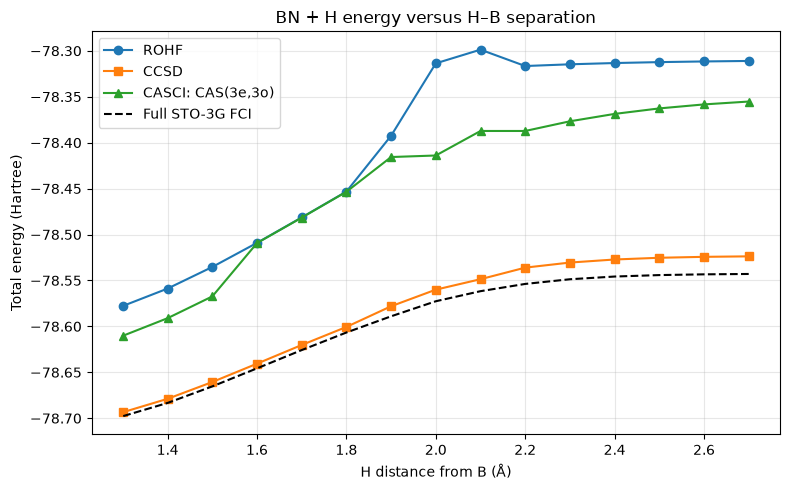

In [7]:
rohf_arr = np.asarray(rohf_arr)
ccsd_arr = np.asarray(ccsd_arr)
casci_arr = np.asarray(casci_arr)
active_fci_arr = np.asarray(active_fci_arr)
full_fci_arr = np.asarray(full_fci_arr)

plt.figure(figsize=(8, 5))

plt.plot(
    h_distances,
    rohf_arr,
    marker="o",
    label="ROHF",
)

plt.plot(
    h_distances,
    ccsd_arr,
    marker="s",
    label="CCSD",
)

plt.plot(
    h_distances,
    casci_arr,
    marker="^",
    label="CASCI: CAS(3e,3o)",
)

plt.plot(
    h_distances,
    full_fci_arr,
    linestyle="--",
    color="black",
    label="Full STO-3G FCI",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("Total energy (Hartree)")
plt.title("BN + H energy versus H–B separation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

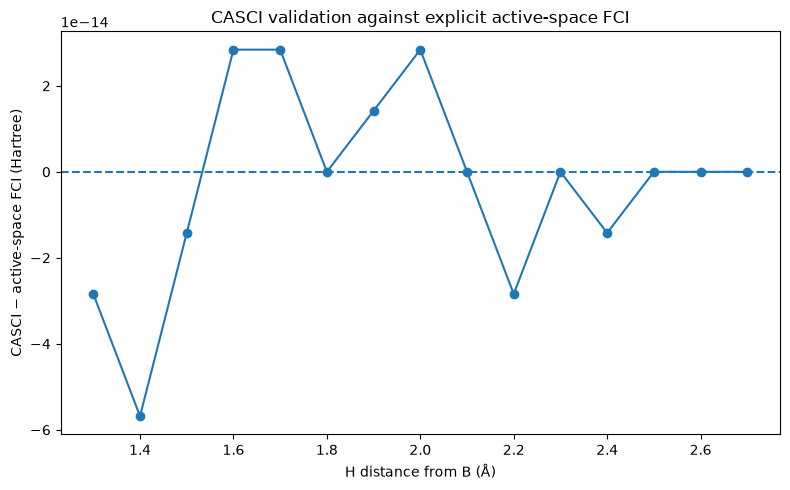

In [8]:
casci_fci_difference = casci_arr - active_fci_arr

plt.figure(figsize=(8, 5))

plt.plot(
    h_distances,
    casci_fci_difference,
    marker="o",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("CASCI − active-space FCI (Hartree)")
plt.title("CASCI validation against explicit active-space FCI")
plt.tight_layout()
plt.show()

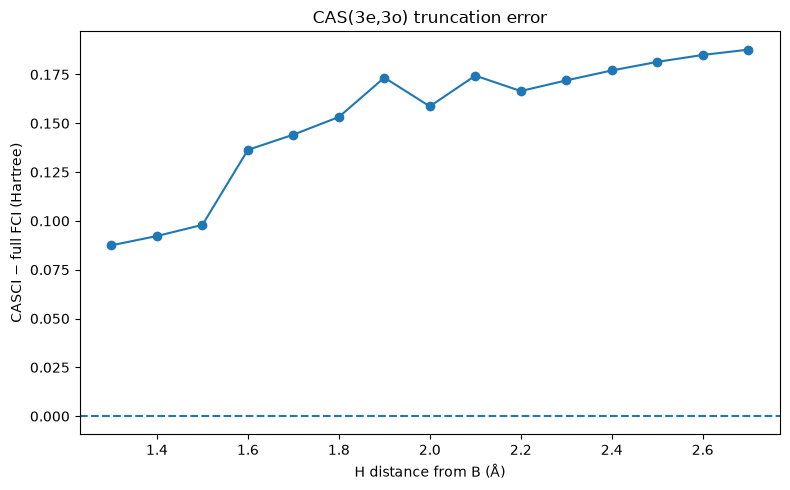

In [9]:
active_space_error = casci_arr - full_fci_arr

plt.figure(figsize=(8, 5))

plt.plot(
    h_distances,
    active_space_error,
    marker="o",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("CASCI − full FCI (Hartree)")
plt.title("CAS(3e,3o) truncation error")
plt.tight_layout()
plt.show()

### Discussion 

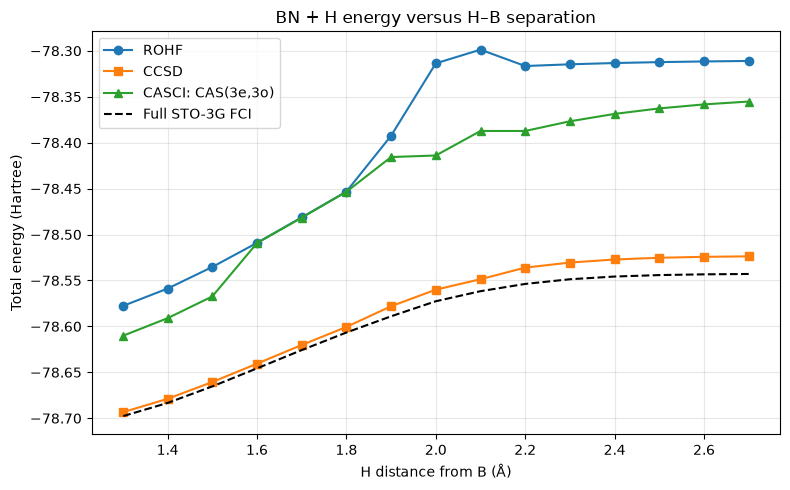

This was a zeroth order experiment trying to see what would happen if we did CASSCF for cas(3e,3o) (3 MOs, 6 qubits, 3 electrons) truncation of the H-BN interation. It is clear there is a constant error between the FCI/CCSD calculation up to 1.80 angstroms, this is expected. The cas(3e,3o) surface becomes a lot more unstable as B-H bond is further disassociated.

Before drawing conclusions, it will be useful to repeat the experiment for larger active spaces. 

## Testing differient active spaces

In [10]:
def build_bnh_molecule(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
):
    """
    Construct neutral doublet BNH.

    Geometry:
        B at z = 0
        N at z = +bn_bond
        H at z = -h_distance
    """
    mol = gto.Mole()

    mol.atom = f"""
    B   0.000000   0.000000    0.000000
    N   0.000000   0.000000    {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 1
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    return mol


def validate_active_space(mol, ncas, nelecas):
    """
    Validate an open-shell CAS specification.

    Parameters
    ----------
    ncas : int
        Number of active spatial orbitals.

    nelecas : tuple[int, int]
        Number of active alpha and beta electrons.
    """
    if (
        not isinstance(nelecas, tuple)
        or len(nelecas) != 2
    ):
        raise TypeError(
            "nelecas must be a tuple "
            "(n_alpha_active, n_beta_active)."
        )

    nalpha, nbeta = nelecas
    n_active = nalpha + nbeta
    n_core_electrons = mol.nelectron - n_active

    if nalpha < 0 or nbeta < 0:
        raise ValueError(
            "Active electron numbers must be non-negative."
        )

    if nalpha > ncas or nbeta > ncas:
        raise ValueError(
            f"Invalid CAS({n_active}e,{ncas}o): "
            "n_alpha and n_beta cannot exceed ncas."
        )

    if n_core_electrons < 0:
        raise ValueError(
            "The active space contains more electrons "
            "than the molecule."
        )

    if n_core_electrons % 2 != 0:
        raise ValueError(
            f"CAS({n_active}e,{ncas}o) leaves "
            f"{n_core_electrons} inactive electrons. "
            "The inactive core must contain an even "
            "number of electrons."
        )

    ncore = n_core_electrons // 2
    nmo = mol.nao_nr()

    if ncore + ncas > nmo:
        raise ValueError(
            f"CAS requires {ncore + ncas} orbitals, "
            f"but only {nmo} molecular orbitals exist."
        )

    return ncore


def run_full_space_references(mol):
    """
    Calculate ROHF, full-space CCSD and full-space FCI.

    Returns
    -------
    dict
        Energies and converged method objects.
    """
    # --------------------------------------------------
    # ROHF
    # --------------------------------------------------
    mf = scf.ROHF(mol)
    mf.conv_tol = 1e-10
    mf.max_cycle = 200
    mf.kernel()

    if not mf.converged:
        # Second-order SCF fallback.
        mf_newton = mf.newton()
        mf_newton.conv_tol = 1e-10
        mf_newton.max_cycle = 100
        mf_newton.kernel()

        if not mf_newton.converged:
            raise RuntimeError(
                "ROHF did not converge."
            )

        mf = mf_newton

    # --------------------------------------------------
    # Full-space CCSD
    # --------------------------------------------------
    mycc = cc.CCSD(mf)
    mycc.conv_tol = 1e-9
    mycc.conv_tol_normt = 1e-7
    mycc.max_cycle = 200

    mycc.kernel()

    if not mycc.converged:
        raise RuntimeError(
            "CCSD did not converge."
        )

    # --------------------------------------------------
    # Full-space FCI
    # --------------------------------------------------
    nmo = mf.mo_coeff.shape[1]

    h1_full = mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff

    eri_full = ao2mo.kernel(
        mol,
        mf.mo_coeff,
    )
    eri_full = ao2mo.restore(
        1,
        eri_full,
        nmo,
    )

    full_fci_solver = fci.direct_spin1.FCI(mol)
    full_fci_solver.conv_tol = 1e-10

    e_full_fci, ci_full_fci = full_fci_solver.kernel(
        h1_full,
        eri_full,
        nmo,
        mol.nelec,
        ecore=mol.energy_nuc(),
    )

    return {
        "mf": mf,
        "cc": mycc,
        "e_rohf": mf.e_tot,
        "e_ccsd": mycc.e_tot,
        "e_full_fci": e_full_fci,
        "ci_full_fci": ci_full_fci,
    }


def run_casci_space(
    mf,
    ncas,
    nelecas,
):
    """
    Run CASCI for one selected active space.

    CASCI is the exact FCI solution within the active
    orbitals selected from the ROHF orbital ordering.
    """
    mol = mf.mol
    ncore = validate_active_space(
        mol,
        ncas,
        nelecas,
    )

    mc = mcscf.CASCI(
        mf,
        ncas,
        nelecas,
    )

    mc.conv_tol = 1e-10
    e_casci, ci_vector = mc.kernel()[:2]

    if not mc.converged:
        raise RuntimeError(
            f"CASCI failed for ncas={ncas}, "
            f"nelecas={nelecas}."
        )

    # Integrals needed later for the quantum Hamiltonian.
    h1eff, ecore = mc.get_h1eff()
    eri_cas = ao2mo.restore(
        1,
        mc.get_h2eff(),
        ncas,
    )

    # Optional explicit active-space FCI verification.
    # PySCF's direct_spin1 solver supports open-shell
    # sectors such as doublets. The kernel accepts h1e,
    # eri, norb, nelec and ecore. 
    # Official API:
    # pyscf.fci.direct_spin1
    active_solver = fci.direct_spin1.FCI(mol)

    e_active_fci, _ = active_solver.kernel(
        h1eff,
        eri_cas,
        ncas,
        nelecas,
        ecore=ecore,
    )

    return {
        "mc": mc,
        "ncas": ncas,
        "nelecas": nelecas,
        "ncore": ncore,
        "nqubits": 2 * ncas,
        "h1eff": h1eff,
        "eri_cas": eri_cas,
        "ecore": ecore,
        "e_casci": e_casci,
        "e_active_fci": e_active_fci,
        "casci_fci_check": e_casci - e_active_fci,
        "ci_vector": ci_vector,
    }


def run_active_space_experiment(
    h_distances,
    active_spaces,
    basis="sto-3g",
    bn_bond=1.281,
):
    """
    Compare multiple CASCI spaces with full-space CCSD
    and full-space FCI along the H-B approach coordinate.

    Parameters
    ----------
    h_distances : iterable[float]
        H-B separations in Angstrom.

    active_spaces : dict
        Mapping from label to:
            {
                "ncas": int,
                "nelecas": (nalpha, nbeta)
            }

    Returns
    -------
    results : dict
        Arrays of energies and errors.
    """
    h_distances = np.asarray(
        h_distances,
        dtype=float,
    )

    results = {
        "h_distances": h_distances,
        "rohf": [],
        "ccsd": [],
        "full_fci": [],
        "active_spaces": {
            label: {
                "ncas": settings["ncas"],
                "nelecas": settings["nelecas"],
                "nqubits": 2 * settings["ncas"],
                "casci": [],
                "active_fci": [],
                "casci_fci_check": [],
            }
            for label, settings in active_spaces.items()
        },
    }

    for r in h_distances:
        print(f"\n{'=' * 72}")
        print(f"H-B distance = {r:.3f} Å")
        print(f"{'=' * 72}")

        mol = build_bnh_molecule(
            basis=basis,
            bn_bond=bn_bond,
            h_distance=r,
        )

        try:
            references = run_full_space_references(
                mol
            )
        except RuntimeError as error:
            print(
                f"Skipping R = {r:.3f} Å: {error}"
            )

            results["rohf"].append(np.nan)
            results["ccsd"].append(np.nan)
            results["full_fci"].append(np.nan)

            for label in active_spaces:
                results["active_spaces"][label][
                    "casci"
                ].append(np.nan)

                results["active_spaces"][label][
                    "active_fci"
                ].append(np.nan)

                results["active_spaces"][label][
                    "casci_fci_check"
                ].append(np.nan)

            continue

        mf = references["mf"]

        results["rohf"].append(
            references["e_rohf"]
        )
        results["ccsd"].append(
            references["e_ccsd"]
        )
        results["full_fci"].append(
            references["e_full_fci"]
        )

        print(
            f"ROHF     = "
            f"{references['e_rohf']:.10f} Ha"
        )
        print(
            f"CCSD     = "
            f"{references['e_ccsd']:.10f} Ha"
        )
        print(
            f"Full FCI = "
            f"{references['e_full_fci']:.10f} Ha"
        )

        for label, settings in active_spaces.items():
            cas_result = run_casci_space(
                mf=mf,
                ncas=settings["ncas"],
                nelecas=settings["nelecas"],
            )

            results["active_spaces"][label][
                "casci"
            ].append(
                cas_result["e_casci"]
            )

            results["active_spaces"][label][
                "active_fci"
            ].append(
                cas_result["e_active_fci"]
            )

            results["active_spaces"][label][
                "casci_fci_check"
            ].append(
                cas_result["casci_fci_check"]
            )

            truncation_error = (
                cas_result["e_casci"]
                - references["e_full_fci"]
            )

            print(
                f"{label:12s} | "
                f"{cas_result['nqubits']:2d} qubits | "
                f"E = {cas_result['e_casci']:.10f} Ha | "
                f"E_CAS - E_FCI = "
                f"{truncation_error:+.6e} Ha | "
                f"CASCI check = "
                f"{cas_result['casci_fci_check']:+.2e} Ha"
            )

    # Convert all lists to NumPy arrays.
    results["rohf"] = np.asarray(
        results["rohf"]
    )
    results["ccsd"] = np.asarray(
        results["ccsd"]
    )
    results["full_fci"] = np.asarray(
        results["full_fci"]
    )

    for label in active_spaces:
        for key in [
            "casci",
            "active_fci",
            "casci_fci_check",
        ]:
            results["active_spaces"][label][key] = (
                np.asarray(
                    results["active_spaces"][label][key]
                )
            )

    return results

def print_active_space_information(
    mol,
    mf,
    ncas,
    nelecas,
):
    n_active_electrons = sum(nelecas)
    ncore = (
        mol.nelectron - n_active_electrons
    ) // 2

    nmo = mf.mo_coeff.shape[1]

    core_indices = list(
        range(0, ncore)
    )

    active_indices = list(
        range(ncore, ncore + ncas)
    )

    external_indices = list(
        range(ncore + ncas, nmo)
    )

    print("\nOrbital-space partition")
    print("-----------------------")
    print("Core indices:    ", core_indices)
    print("Active indices:  ", active_indices)
    print("External indices:", external_indices)

    print("\nMO information")
    print("--------------")

    for i in range(nmo):
        if i in core_indices:
            space = "core"
        elif i in active_indices:
            space = "active"
        else:
            space = "external"

        print(
            f"MO {i:2d} | "
            f"{space:8s} | "
            f"energy = {mf.mo_energy[i]: .8f} | "
            f"occupation = {mf.mo_occ[i]:.1f}"
        )

def print_mo_composition(
    mol,
    mf,
    threshold=0.05,
):
    """
    Print approximate AO contributions to each ROHF MO.

    Contributions are evaluated using squared coefficients in
    an orthogonalised AO basis.
    """
    s_ao = mol.intor("int1e_ovlp")

    # Symmetric orthogonalisation matrix S^(1/2).
    s_eigvals, s_eigvecs = np.linalg.eigh(s_ao)

    s_half = (
        s_eigvecs
        @ np.diag(np.sqrt(s_eigvals))
        @ s_eigvecs.T
    )

    # MO coefficients in an orthogonal AO representation.
    c_orth = s_half @ mf.mo_coeff

    ao_labels = mol.ao_labels()

    for imo in range(mf.mo_coeff.shape[1]):
        weights = np.abs(c_orth[:, imo]) ** 2
        weights /= np.sum(weights)

        print(
            f"\nMO {imo:2d} | "
            f"energy = {mf.mo_energy[imo]: .6f} | "
            f"occupation = {mf.mo_occ[imo]:.1f}"
        )

        order = np.argsort(weights)[::-1]

        for iao in order:
            if weights[iao] < threshold:
                break

            print(
                f"    {ao_labels[iao]}: "
                f"{100 * weights[iao]:6.2f}%"
            )

In [11]:
h_distances = np.array([
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
    2.0,
    2.1,
    2.2,
    2.3,
])

active_spaces = {
    "CAS(3e,3o)": {
        "ncas": 3,
        "nelecas": (2, 1),
    },
    "CAS(5e,5o)": {
        "ncas": 5,
        "nelecas": (3, 2),
    },
    "CAS(7e,7o)": {
        "ncas": 7,
        "nelecas": (4, 3),
    },
    "CAS(9e,9o)": {
        "ncas": 9,
        "nelecas": (5, 4),
    },
}

results = run_active_space_experiment(
    h_distances=h_distances,
    active_spaces=active_spaces,
)


H-B distance = 0.900 Å
ROHF     = -78.5286532058 Ha
CCSD     = -78.6349134578 Ha
Full FCI = -78.6387060395 Ha
CAS(3e,3o)   |  6 qubits | E = -78.5628453095 Ha | E_CAS - E_FCI = +7.586073e-02 Ha | CASCI check = +0.00e+00 Ha
CAS(5e,5o)   | 10 qubits | E = -78.5849223009 Ha | E_CAS - E_FCI = +5.378374e-02 Ha | CASCI check = +4.28e-10 Ha
CAS(7e,7o)   | 14 qubits | E = -78.6041019725 Ha | E_CAS - E_FCI = +3.460407e-02 Ha | CASCI check = +8.13e-10 Ha
CAS(9e,9o)   | 18 qubits | E = -78.6381229167 Ha | E_CAS - E_FCI = +5.831228e-04 Ha | CASCI check = +4.43e-10 Ha

H-B distance = 1.000 Å
ROHF     = -78.5728079696 Ha
CCSD     = -78.6803896362 Ha
Full FCI = -78.6842633874 Ha
CAS(3e,3o)   |  6 qubits | E = -78.6064404400 Ha | E_CAS - E_FCI = +7.782295e-02 Ha | CASCI check = -1.42e-14 Ha
CAS(5e,5o)   | 10 qubits | E = -78.6282764811 Ha | E_CAS - E_FCI = +5.598691e-02 Ha | CASCI check = +3.95e-10 Ha
CAS(7e,7o)   | 14 qubits | E = -78.6477881997 Ha | E_CAS - E_FCI = +3.647519e-02 Ha | CASCI check = 

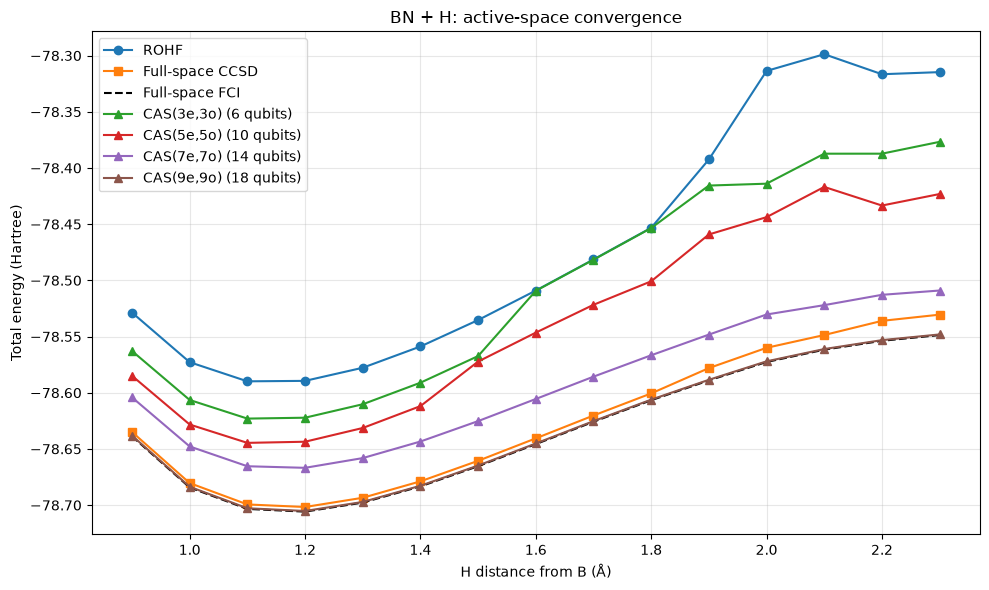

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    results["h_distances"],
    results["rohf"],
    marker="o",
    label="ROHF",
)

plt.plot(
    results["h_distances"],
    results["ccsd"],
    marker="s",
    label="Full-space CCSD",
)

plt.plot(
    results["h_distances"],
    results["full_fci"],
    linestyle="--",
    color="black",
    label="Full-space FCI",
)

for label, data in results["active_spaces"].items():
    plt.plot(
        results["h_distances"],
        data["casci"],
        marker="^",
        label=f"{label} ({data['nqubits']} qubits)",
    )

plt.xlabel("H distance from B (Å)")
plt.ylabel("Total energy (Hartree)")
plt.title("BN + H: active-space convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

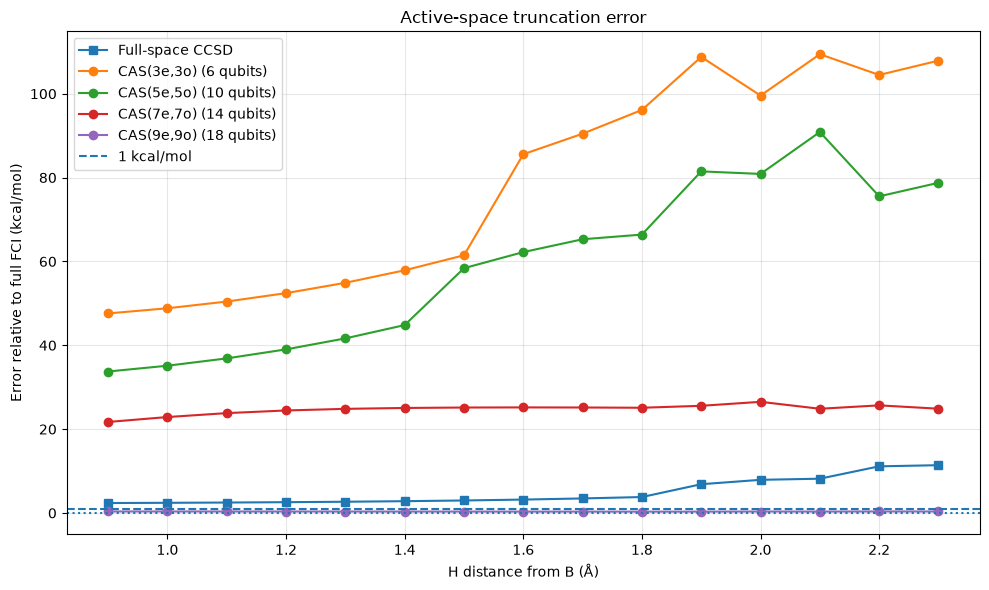

In [13]:
HARTREE_TO_KCAL_MOL = 627.509474

plt.figure(figsize=(10, 6))

ccsd_error = (
    results["ccsd"]
    - results["full_fci"]
) * HARTREE_TO_KCAL_MOL

plt.plot(
    results["h_distances"],
    ccsd_error,
    marker="s",
    label="Full-space CCSD",
)

for label, data in results["active_spaces"].items():
    cas_error = (
        data["casci"]
        - results["full_fci"]
    ) * HARTREE_TO_KCAL_MOL

    plt.plot(
        results["h_distances"],
        cas_error,
        marker="o",
        label=f"{label} ({data['nqubits']} qubits)",
    )

plt.axhline(
    1.0,
    linestyle="--",
    label="1 kcal/mol",
)

plt.axhline(
    0.0,
    linestyle=":",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("Error relative to full FCI (kcal/mol)")
plt.title("Active-space truncation error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

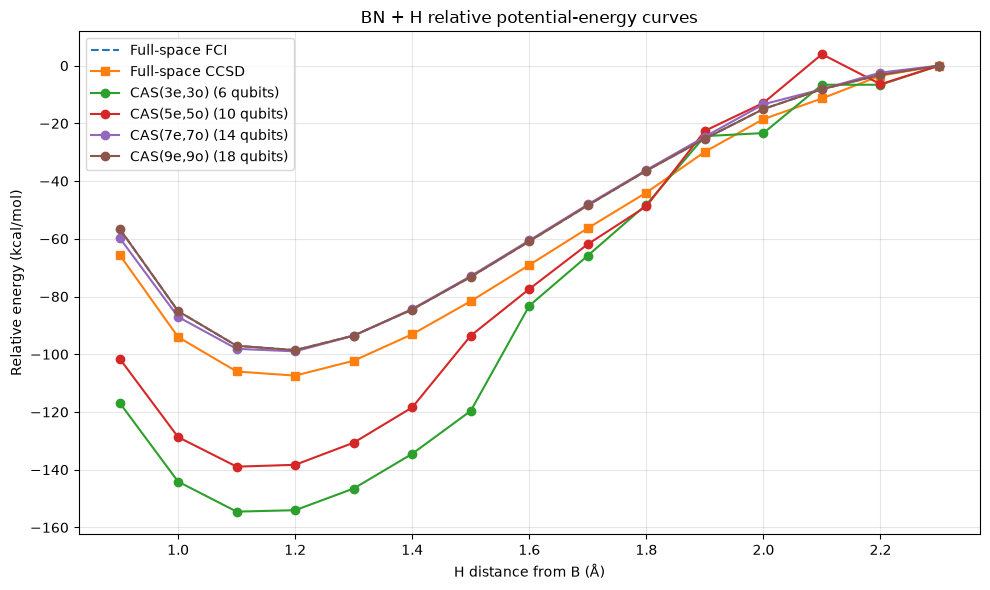

In [14]:
def reference_to_last_finite_point(energies):
    energies = np.asarray(
        energies,
        dtype=float,
    )

    finite_indices = np.where(
        np.isfinite(energies)
    )[0]

    if len(finite_indices) == 0:
        return np.full_like(
            energies,
            np.nan,
        )

    reference = energies[
        finite_indices[-1]
    ]

    return energies - reference


plt.figure(figsize=(10, 6))

fci_relative = reference_to_last_finite_point(
    results["full_fci"]
)

ccsd_relative = reference_to_last_finite_point(
    results["ccsd"]
)

plt.plot(
    results["h_distances"],
    fci_relative * HARTREE_TO_KCAL_MOL,
    linestyle="--",
    label="Full-space FCI",
)

plt.plot(
    results["h_distances"],
    ccsd_relative * HARTREE_TO_KCAL_MOL,
    marker="s",
    label="Full-space CCSD",
)

for label, data in results["active_spaces"].items():
    cas_relative = reference_to_last_finite_point(
        data["casci"]
    )

    plt.plot(
        results["h_distances"],
        cas_relative * HARTREE_TO_KCAL_MOL,
        marker="o",
        label=f"{label} ({data['nqubits']} qubits)",
    )

plt.xlabel("H distance from B (Å)")
plt.ylabel("Relative energy (kcal/mol)")
plt.title("BN + H relative potential-energy curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

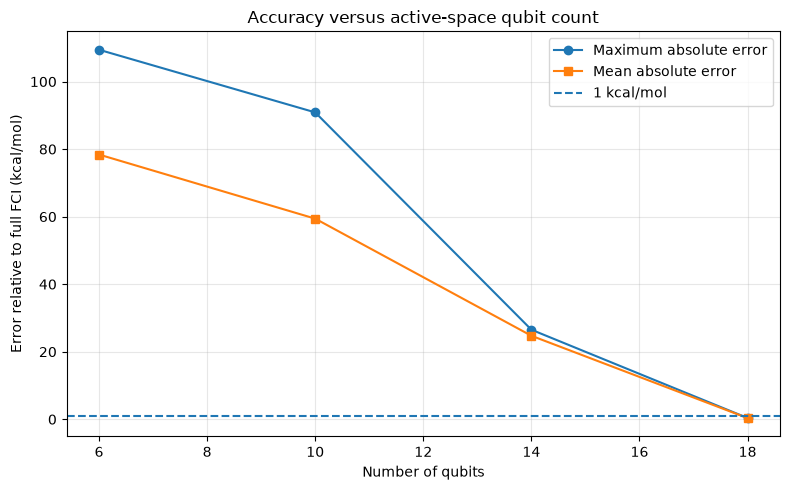

In [15]:
qubit_counts = []
maximum_errors = []
mean_errors = []

for label, data in results["active_spaces"].items():
    error = np.abs(
        data["casci"]
        - results["full_fci"]
    ) * HARTREE_TO_KCAL_MOL

    qubit_counts.append(
        data["nqubits"]
    )
    maximum_errors.append(
        np.nanmax(error)
    )
    mean_errors.append(
        np.nanmean(error)
    )

qubit_counts = np.asarray(qubit_counts)
maximum_errors = np.asarray(maximum_errors)
mean_errors = np.asarray(mean_errors)

order = np.argsort(qubit_counts)

plt.figure(figsize=(8, 5))

plt.plot(
    qubit_counts[order],
    maximum_errors[order],
    marker="o",
    label="Maximum absolute error",
)

plt.plot(
    qubit_counts[order],
    mean_errors[order],
    marker="s",
    label="Mean absolute error",
)

plt.axhline(
    1.0,
    linestyle="--",
    label="1 kcal/mol",
)

plt.xlabel("Number of qubits")
plt.ylabel("Error relative to full FCI (kcal/mol)")
plt.title("Accuracy versus active-space qubit count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion 

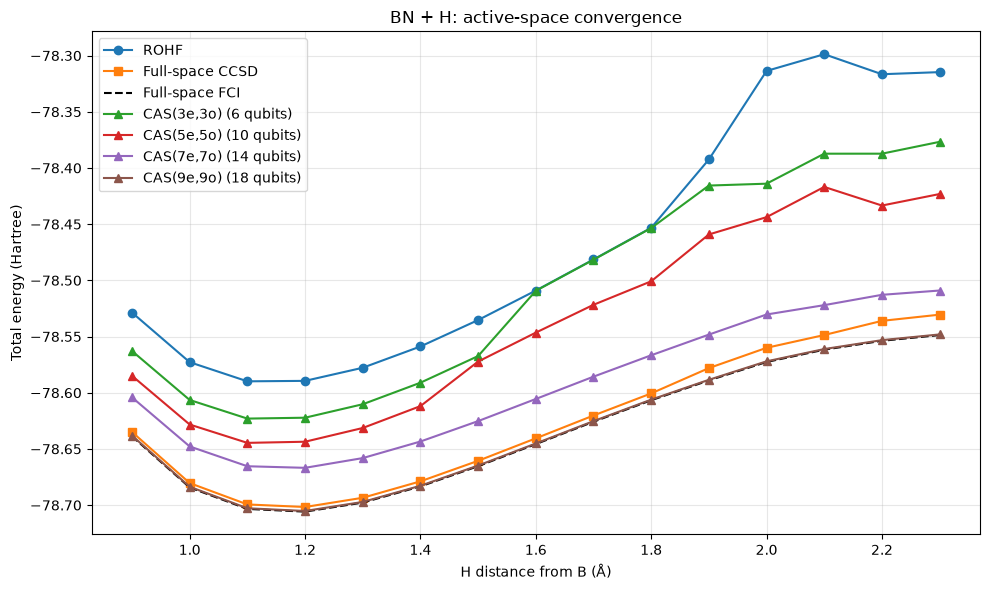

The CAS(9e,9o) seems to do the best job at resolving the system - it is qualitatively competitive with FCI and better than CCSD. 

CAS(3e,3o) and CAS(5e,5o) seems to be of until 1.4 (maybes my previous sim was a bit wrong lelelelelel). But both become unstable as the B-H bond is further disassociated 

My initial thought was that aggressively reducing the active space restricts the set of many-electron configurations available to the post-HF wavefunction. Electrons in frozen core orbitals are constrained to remain doubly occupied, while external orbitals remain unoccupied, so configurations involving excitations from the frozen space into the active or external spaces cannot contribute.

Come to think of it, it only seems to explain why small active spaces may give inaccurate results relative to FCI, buy it doesn't explain why they smaller active spaces give PES that is stable when B-H bond is near equilibium but not when it's disassociated. To understand this, I decided to study how orbital occupancy changes as we stretch B-H bond. 

## Investigating orbital occupancy

In [16]:
def run_rohf(
    mol,
    conv_tol=1e-10,
    max_cycle=200,
):
    """
    Run ROHF with a Newton fallback.
    """
    mf = scf.ROHF(mol)
    mf.conv_tol = conv_tol
    mf.max_cycle = max_cycle
    mf.kernel()

    if not mf.converged:
        print("Standard ROHF failed; trying Newton ROHF.")

        mf = mf.newton()
        mf.conv_tol = conv_tol
        mf.max_cycle = 100
        mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge.")

    return mf


def run_casci_with_natural_occupations(
    mf,
    ncas=9,
    nelecas=(5, 4),
):
    """
    Run CASCI and calculate active-space natural occupations.

    For BNH:
        CAS(9e,9o) corresponds to the full STO-3G
        valence space after freezing the B and N 1s cores.
    """
    mc = mcscf.CASCI(
        mf,
        ncas,
        nelecas,
    )

    mc.conv_tol = 1e-10
    e_casci = mc.kernel()[0]

    if not mc.converged:
        raise RuntimeError("CASCI did not converge.")

    # Spin-summed one-particle density matrix
    # within the active orbital basis.
    casdm1 = mc.fcisolver.make_rdm1(
        mc.ci,
        mc.ncas,
        mc.nelecas,
    )

    # Diagonalise the active-space 1-RDM.
    occupations, natural_orbital_rotation = np.linalg.eigh(
        casdm1
    )

    # Sort from highest occupation to lowest.
    order = np.argsort(occupations)[::-1]

    occupations = occupations[order]
    natural_orbital_rotation = (
        natural_orbital_rotation[:, order]
    )

    return {
        "mc": mc,
        "e_casci": e_casci,
        "occupations": occupations,
        "natural_orbital_rotation": (
            natural_orbital_rotation
        ),
        "casdm1": casdm1,
    }

h_distances = np.array([
    1.3,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
    2.0,
    2.1,
    2.2,
    2.3,
    2.4,
    2.5,
    2.6,
    2.7,
])

occupation_arr = []
cas9_energy_arr = []

all_cas9_results = []

for r in h_distances:
    print(f"\nH-B distance = {r:.2f} Å")

    mol = build_bnh_molecule(
        h_distance=r,
    )

    mf = run_rohf(mol)

    cas9_result = run_casci_with_natural_occupations(
        mf,
        ncas=9,
        nelecas=(5, 4),
    )

    occupations = cas9_result["occupations"]

    occupation_arr.append(occupations)
    cas9_energy_arr.append(
        cas9_result["e_casci"]
    )
    all_cas9_results.append(cas9_result)

    print(
        f"CAS(9e,9o) energy = "
        f"{cas9_result['e_casci']:.10f} Ha"
    )

    for i, occupation in enumerate(occupations):
        print(
            f"    Natural orbital {i:2d}: "
            f"{occupation:.8f}"
        )

occupation_arr = np.asarray(occupation_arr)
cas9_energy_arr = np.asarray(cas9_energy_arr)


H-B distance = 1.30 Å
CAS(9e,9o) energy = -78.6971718347 Ha
    Natural orbital  0: 1.98840084
    Natural orbital  1: 1.97455046
    Natural orbital  2: 1.96359799
    Natural orbital  3: 1.91606325
    Natural orbital  4: 0.98121276
    Natural orbital  5: 0.08610564
    Natural orbital  6: 0.04074273
    Natural orbital  7: 0.03432147
    Natural orbital  8: 0.01500486

H-B distance = 1.40 Å
CAS(9e,9o) energy = -78.6827678434 Ha
    Natural orbital  0: 1.98841007
    Natural orbital  1: 1.97361958
    Natural orbital  2: 1.95204266
    Natural orbital  3: 1.91590736
    Natural orbital  4: 0.98117916
    Natural orbital  5: 0.08632813
    Natural orbital  6: 0.05169973
    Natural orbital  7: 0.03459174
    Natural orbital  8: 0.01622157

H-B distance = 1.50 Å
CAS(9e,9o) energy = -78.6647773540 Ha
    Natural orbital  0: 1.98839680
    Natural orbital  1: 1.97261504
    Natural orbital  2: 1.93638652
    Natural orbital  3: 1.91556203
    Natural orbital  4: 0.98110255
    Natural 

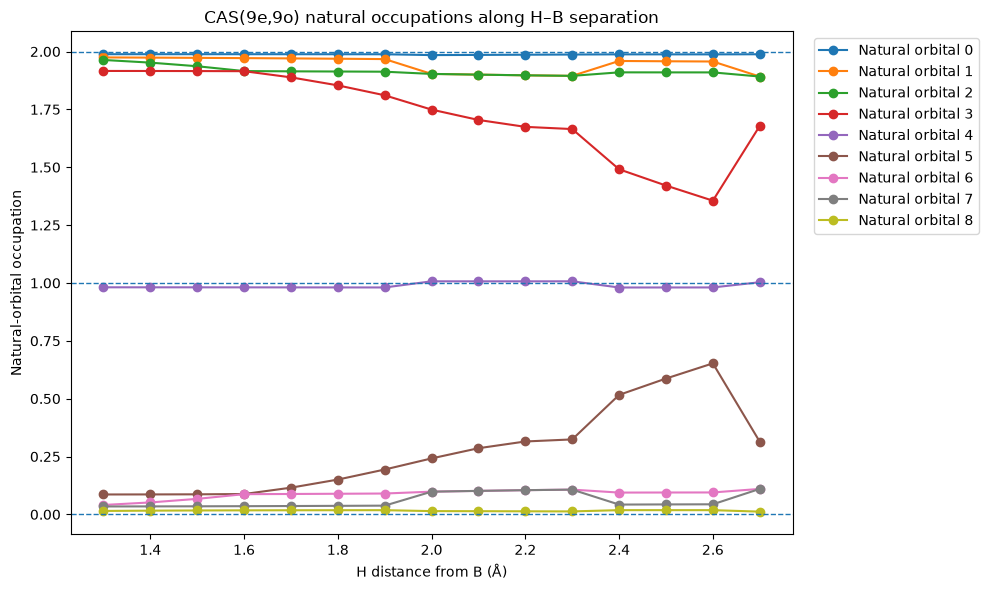

In [17]:
plt.figure(figsize=(10, 6))

for orbital_index in range(occupation_arr.shape[1]):
    plt.plot(
        h_distances,
        occupation_arr[:, orbital_index],
        marker="o",
        label=f"Natural orbital {orbital_index}",
    )

plt.axhline(
    2.0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("Natural-orbital occupation")
plt.title("CAS(9e,9o) natural occupations along H–B separation")
plt.legend(
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
)
plt.tight_layout()
plt.show()

In [18]:
def occupation_fractionality(occupations):
    """
    Measure the deviation of natural occupations from
    the nearest of 0, 1 or 2.
    """
    occupations = np.asarray(occupations)

    distance_to_0 = np.abs(occupations)
    distance_to_1 = np.abs(occupations - 1.0)
    distance_to_2 = np.abs(occupations - 2.0)

    return np.minimum.reduce([
        distance_to_0,
        distance_to_1,
        distance_to_2,
    ])


fractionality_arr = np.asarray([
    occupation_fractionality(occupations)
    for occupations in occupation_arr
])

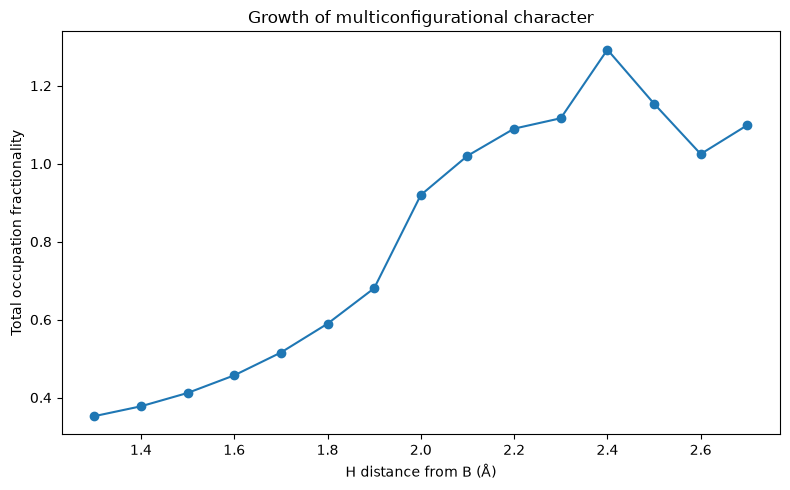

In [19]:
total_fractionality = np.sum(
    fractionality_arr,
    axis=1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    h_distances,
    total_fractionality,
    marker="o",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("Total occupation fractionality")
plt.title("Growth of multiconfigurational character")
plt.tight_layout()
plt.show()

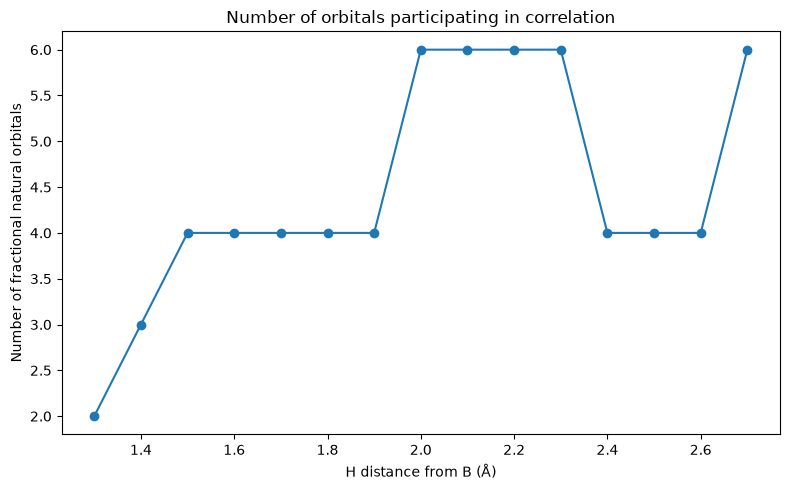

In [20]:
fractional_threshold = 0.05

n_fractional_orbitals = np.sum(
    fractionality_arr > fractional_threshold,
    axis=1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    h_distances,
    n_fractional_orbitals,
    marker="o",
)

plt.xlabel("H distance from B (Å)")
plt.ylabel("Number of fractional natural orbitals")
plt.title(
    "Number of orbitals participating in correlation"
)
plt.tight_layout()
plt.show()

In [21]:
selected_distances = np.array([
    1.3,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
    2.0,
    2.1,
    2.2,
    2.3,
    2.4,
    2.5,
    2.6,
    2.7,
])

for target_distance in selected_distances:
    index = np.argmin(
        np.abs(h_distances - target_distance)
    )

    print(
        f"\nNatural occupations at "
        f"R = {h_distances[index]:.2f} Å"
    )

    for orbital_index, occupation in enumerate(
        occupation_arr[index]
    ):
        print(
            f"    NO {orbital_index:2d}: "
            f"{occupation:.8f}"
        )


Natural occupations at R = 1.30 Å
    NO  0: 1.98840084
    NO  1: 1.97455046
    NO  2: 1.96359799
    NO  3: 1.91606325
    NO  4: 0.98121276
    NO  5: 0.08610564
    NO  6: 0.04074273
    NO  7: 0.03432147
    NO  8: 0.01500486

Natural occupations at R = 1.40 Å
    NO  0: 1.98841007
    NO  1: 1.97361958
    NO  2: 1.95204266
    NO  3: 1.91590736
    NO  4: 0.98117916
    NO  5: 0.08632813
    NO  6: 0.05169973
    NO  7: 0.03459174
    NO  8: 0.01622157

Natural occupations at R = 1.50 Å
    NO  0: 1.98839680
    NO  1: 1.97261504
    NO  2: 1.93638652
    NO  3: 1.91556203
    NO  4: 0.98110255
    NO  5: 0.08677268
    NO  6: 0.06714426
    NO  7: 0.03499925
    NO  8: 0.01702088

Natural occupations at R = 1.60 Å
    NO  0: 1.98836313
    NO  1: 1.97149895
    NO  2: 1.91556521
    NO  3: 1.91504735
    NO  4: 0.98099205
    NO  5: 0.08803680
    NO  6: 0.08741954
    NO  7: 0.03553609
    NO  8: 0.01754087

Natural occupations at R = 1.70 Å
    NO  0: 1.98831400
    NO  1: 

### Discussion

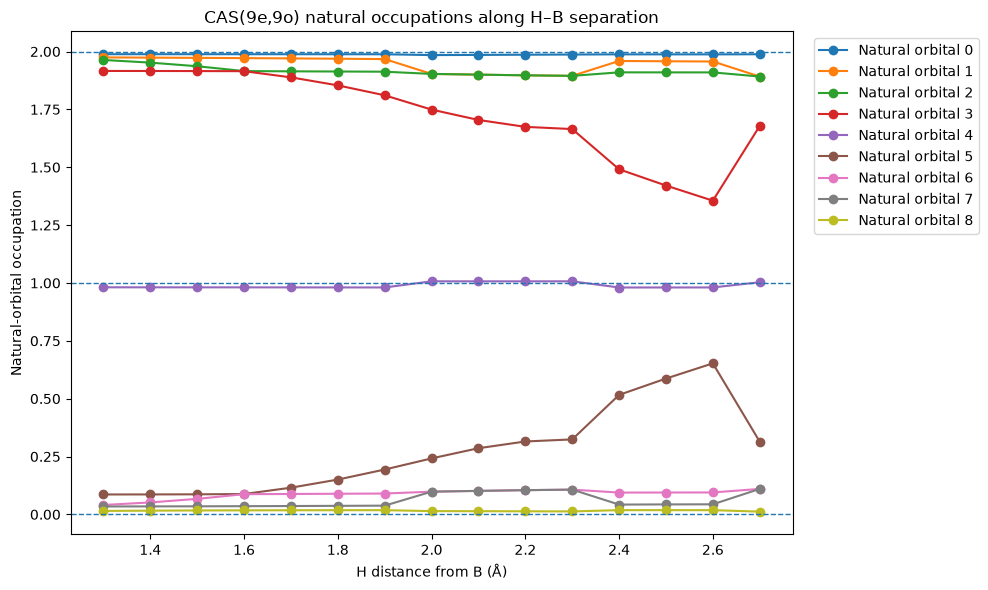

The occupation number graph was constructed by diagonalising the CAS(9e,9o) 1-RDM. The eigenvalues (or the diagonal values) correspond to the spin traced occupation number of natural orbitals. This gives us a snapshot of electron occupation on 9 active space orbitals at a given B-N separation. These occupation numbers are going be fractional rather than natural numbers, because of the wave nature of electrons. 

Up to a serparation of 1.5 angstroms, occupations of 7 orbitals were fairly stable apart from orbs. 6 and 2, even then, they didn't change so much. As separation increased the occupation number of a minority of orbitals changed drastically.

From the CAS(Ne,Mo) calculations previously, we concluded that smaller active spaces were entirely inaccurate but stable near the equilibium bond length (0.9 to 1.4ish), but became further unstable as we increased B-H seperation. I postulated that this is was because that too many frozen core electrons weren't allowed to excite into the active space and restricted space, therefore the post-HF wavefunction wasn't able to resolve a complete set of excitations to accurately represent the system. I also said that this explains the overall in accuracy but doesn't truely address why the smaller active spaces are stable and unstable in separation. 

From the occupation number experiment, we see that near equilibium B-H bond length, the occupation numbers for almost all orbitals are fairly stable. In the context of the post-HF wavefunctions used to descibes B-H seperation close to equlibrium, we can conclude that the probablity amplitudes of higher order excitations aren't high, and a single SD HF-state can describe the system well enough to give a stable (even if inaccurate) pes. This is the region where dynamic correlations dominate; so electrons in the system are close packed (maybe not the right thing to say) and are repelling all other electrons (represented via some average field). 

For separations above 1.6 angstroms, we can see that occupation numbers from a number of natural orbitals change drastically as separation increases. Therefore, the probablity amplitude of high-order excitations increase, thus the more expressive post-HF state allowed, for a CAS(9e,9o) system, can capture the full system more completely. This is when static correlations dominate and the higher excitation coeffs in post-HF expansion increase, sometimes even be degenrate. 


My recommendation to myself is that we will study the CAS(3e,3o), at statevector level to see if the CAS was done successfully. Then do CAS(7e,7o) and CAS(9e,9o)


## Final (corrected) conclusions from PySCF calculation 

The CAS(9e,9o) seems to do the best job at resolving the system. It reproduces the full-space FCI PES extremely closely and is slightly closer to FCI than full-space CCSD.

CAS(3e,3o) and CAS(5e,5o) seem reasonably stable around the equilibrium region, although their absolute energies are poor. As the B–H bond is stretched, however, their PESs become increasingly unreliable.

My initial thought was that aggressively reducing the active space restricts the post-HF state's ability to represent the complete set of relevant many-electron configurations. Frozen orbitals are constrained to fixed occupations, and external orbitals cannot be occupied, so configurations involving electron redistribution through these orbitals are removed from the FCI expansion. Importantly, CASCI is still FCI within the selected active space; the restriction is therefore on the available orbital/configuration space rather than directly on excitation rank.

This explains why small active spaces lose correlation energy relative to full-space FCI, but it does not by itself explain why the PES can remain smooth near equilibrium and then deteriorate on dissociation. To investigate this, I studied how the electronic occupations change as the B–H bond is stretched.

The occupation-number graph was constructed by diagonalising the spin-summed CAS(9e,9o) one-particle reduced density matrix. Its eigenvectors define the natural orbitals and its eigenvalues give their occupations. A single-determinant doublet would have natural occupations approximately (2,2,2,2,1,0,0,0,0). Deviations from these integer values therefore provide a measure of the multiconfigurational character of the correlated state.

Near the equilibrium B–H distance, most natural occupations remain relatively close to 2, 1, or 0. The state is therefore comparatively single-reference-like: the ROHF determinant remains a reasonable qualitative description, while additional configurations mainly provide correlation corrections. This is consistent with a predominantly dynamically correlated regime.

As the B–H bond is stretched, some natural occupations change dramatically. In particular, occupation is transferred from an orbital that was nearly doubly occupied into one that was previously only weakly occupied. This indicates that multiple electron configurations with different orbital occupations become increasingly important. The wavefunction therefore acquires stronger multireference/static-correlation character.

This provides an explanation for the failure of very small active spaces during dissociation. Near equilibrium, the important configurations fit reasonably well inside a compact set of active orbitals, so excluding other orbitals largely produces a smooth correlation-energy error. At larger separations, additional valence configurations become nearly degenerate and acquire substantial weight. If the orbitals needed to represent these configurations are frozen or excluded, the small CAS can no longer continuously represent the changing electronic state, and its PES becomes unreliable.

My recommendation is therefore to use CAS(3e,3o) initially at statevector level as a minimal implementation/debugging case, and then focus the physically meaningful calculations on CAS(7e,7o) and CAS(9e,9o), corresponding to 14 and 18 qubits respectively. CAS(9e,9o) provides the near-FCI valence-space benchmark, while CAS(7e,7o) appears to preserve the relevant PES physics at substantially reduced qubit cost.

## Moments and VQE energy only for CAS(3e,3o) (6 qubits) 



In [6]:
def build_bnh_molecule(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
):
    """
    Construct neutral doublet BNH.

    Geometry:
        B at z = 0
        N at z = +bn_bond
        H at z = -h_distance
    """
    mol = gto.Mole()

    mol.atom = f"""
    B   0.000000   0.000000    0.000000
    N   0.000000   0.000000    {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 1
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    return mol

def run_rohf(
    mol,
    conv_tol=1e-10,
    max_cycle=200,
):
    """
    Run ROHF with a Newton fallback.
    """
    mf = scf.ROHF(mol)
    mf.conv_tol = conv_tol
    mf.max_cycle = max_cycle
    mf.kernel()

    if not mf.converged:
        print("Standard ROHF failed; trying Newton ROHF.")

        mf = mf.newton()
        mf.conv_tol = conv_tol
        mf.max_cycle = 100
        mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge.")

    return mf

class CASSpectralMoments:
    """
    CASCI + VQE + spectral-moment calculator.

    The class constructs the effective active-space Hamiltonian

        H_CAS = E_core
              + sum_pq h_eff[p,q] a_p^dag a_q
              + 1/2 sum_pqrs g[p,q,r,s]
                    a_p^dag a_q^dag a_s a_r

    and maps it to qubits using Jordan-Wigner.

    The intended workflow is:

        PySCF ROHF
            ->
        CAS active-space Hamiltonian
            ->
        exact CASCI reference
            ->
        UCCSD-VQE approximation
            ->
        hole / particle spectral moments
            ->
        Green's-function reconstruction
    """

    def __init__(
        self,
        mf,
        ncas,
        nelecas,
        mo_coeff=None,
        mapping="jordan_wigner",
    ):

        self.mf = mf
        self.mol = mf.mol

        self.ncas = int(ncas)

        # --------------------------------------------------
        # Active electron numbers
        # --------------------------------------------------
        self.nelec_alpha = int(nelecas[0])
        self.nelec_beta = int(nelecas[1])

        self.nelec_tuple = (
            self.nelec_alpha,
            self.nelec_beta,
        )

        # Integer active-electron number used by PennyLane.
        self.nelec = (
            self.nelec_alpha
            + self.nelec_beta
        )

        self.nmo = self.ncas
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(
            range(self.n_spin_orbitals)
        )

        self.mapping = mapping

        # --------------------------------------------------
        # Basic consistency checks
        # --------------------------------------------------
        if self.nelec_alpha > self.ncas:
            raise ValueError(
                "Number of alpha electrons exceeds "
                "number of active spatial orbitals."
            )

        if self.nelec_beta > self.ncas:
            raise ValueError(
                "Number of beta electrons exceeds "
                "number of active spatial orbitals."
            )

        ncore_electrons = (
            self.mol.nelectron
            - self.nelec
        )

        if ncore_electrons < 0:
            raise ValueError(
                "Active space contains more electrons "
                "than the full molecule."
            )

        if ncore_electrons % 2 != 0:
            raise ValueError(
                "Inactive electrons must form a "
                "closed-shell core."
            )

        self.ncore = (
            ncore_electrons // 2
        )

        # --------------------------------------------------
        # Molecular orbitals
        # --------------------------------------------------
        if mo_coeff is None:
            mo_coeff = mf.mo_coeff

        self.mo_coeff = mo_coeff

        # --------------------------------------------------
        # PySCF CASCI object
        # --------------------------------------------------
        self.cas = mcscf.CASCI(
            mf,
            self.ncas,
            self.nelec_tuple,
        )

        # --------------------------------------------------
        # Effective CAS Hamiltonian
        # --------------------------------------------------
        self.h1eff, self.ecore = (
            self.cas.get_h1eff(
                self.mo_coeff
            )
        )

        eri_cas = self.cas.get_h2eff(
            self.mo_coeff
        )

        eri_cas = ao2mo.restore(
            1,
            eri_cas,
            self.ncas,
        )

        self.one_mo = np.asarray(
            self.h1eff
        )

        # PennyLane two_particle uses
        # <p,q|v|r,s> with annihilation order r,s.
        # PySCF ERIs therefore need this rearrangement.
        self.two_mo = np.swapaxes(
            eri_cas,
            1,
            3,
        )

        self.constant_energy = float(
            self.ecore
        )

        # --------------------------------------------------
        # Build qubit Hamiltonian
        # --------------------------------------------------
        self.qubit_hamiltonian = (
            self.build_qubit_hamiltonian()
        )

        # --------------------------------------------------
        # PennyLane device
        # --------------------------------------------------
        self.device = qml.device(
            "default.qubit",
            wires=self.n_spin_orbitals,
        )

        # Sparse matrices are built lazily.
        self._H_sparse = None
        self._a_sparse_cache = {}
        self._adag_sparse_cache = {}

    # ======================================================
    # Hamiltonian construction
    # ======================================================

    def build_qubit_hamiltonian(self):

        h1_fermion = one_particle(
            self.one_mo
        )

        h2_fermion = two_particle(
            self.two_mo
        )

        H = observable(
            [
                h1_fermion,
                h2_fermion,
            ],
            init_term=self.ecore,
            mapping=self.mapping,
            wires=self.wires,
        )

        return H
    # ======================================================
    # Exact CASCI reference
    # ======================================================

    def run_exact_casci(self):

        output = self.cas.kernel(
            self.mo_coeff
        )

        e_casci = output[0]
        ci_vector = output[1]

        if not self.cas.converged:
            raise RuntimeError(
                "CASCI did not converge."
            )

        return {
            "casci_energy": float(e_casci),
            "casci_ci": ci_vector,
        }


    # ======================================================
    # Full-space classical comparisons
    # ======================================================

    def pyscf_comparisons(
        self,
        run_fci=True,
        run_ccsd=True,
    ):

        outputs = {
            "rohf_energy": float(
                self.mf.e_tot
            ),
        }

        if run_fci:
            cisolver = fci.FCI(
                self.mf
            )

            fci_energy, fci_vector = (
                cisolver.kernel()
            )

            outputs["fci_energy"] = float(
                fci_energy
            )

            outputs["fci_vector"] = (
                fci_vector
            )

        if run_ccsd:
            try:
                ccsdsolver = cc.CCSD(
                    self.mf
                )

                ccsdsolver.kernel()

                outputs["ccsd_energy"] = (
                    float(
                        ccsdsolver.e_tot
                    )
                )

                outputs[
                    "ccsd_converged"
                ] = ccsdsolver.converged

            except Exception as err:
                outputs["ccsd_energy"] = None
                outputs[
                    "ccsd_converged"
                ] = False
                outputs[
                    "ccsd_error"
                ] = str(err)

        return outputs

    # ======================================================
    # VQE helpers
    # ======================================================

    def _build_uccsd_data(self):

        hf_state = qml.qchem.hf_state(
            self.nelec,
            self.n_spin_orbitals,
        )

        singles, doubles = (
            qml.qchem.excitations(
                self.nelec,
                self.n_spin_orbitals,
            )
        )

        s_wires, d_wires = (
            qml.qchem.excitations_to_wires(
                singles,
                doubles,
            )
        )

        return (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        )


    def run_vqe(
        self,
        max_steps=100,
        stepsize=0.1,
        initial_params=None,
        verbose=False,
        conv_tol=None,
    ):

        (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        ) = self._build_uccsd_data()

        dev = self.device

        @qml.qnode(
            dev,
            interface="autograd",
        )
        def energy_qnode(theta):

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.expval(
                self.qubit_hamiltonian
            )

        @qml.qnode(
            dev,
            interface="autograd",
        )
        def state_qnode(theta):

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.state()

        n_params = (
            len(singles)
            + len(doubles)
        )

        if initial_params is None:

            theta = pnp.zeros(
                n_params,
                requires_grad=True,
            )

        else:

            theta = pnp.array(
                initial_params,
                requires_grad=True,
            )

            if len(theta) != n_params:
                raise ValueError(
                    f"Expected {n_params} "
                    f"UCCSD parameters, "
                    f"received {len(theta)}."
                )

        opt = (
            qml.GradientDescentOptimizer(
                stepsize=stepsize
            )
        )

        energy_history = []

        previous_energy = None

        for step in range(max_steps):

            theta, energy_before = (
                opt.step_and_cost(
                    energy_qnode,
                    theta,
                )
            )

            current_energy = float(
                energy_qnode(theta)
            )

            energy_history.append(
                current_energy
            )

            if verbose and step % 10 == 0:

                print(
                    f"Step {step:4d} | "
                    f"E = "
                    f"{current_energy:.12f} Ha"
                )

            if (
                conv_tol is not None
                and previous_energy is not None
            ):

                if abs(
                    current_energy
                    - previous_energy
                ) < conv_tol:

                    if verbose:
                        print(
                            "VQE converged at "
                            f"step {step}."
                        )

                    break

            previous_energy = (
                current_energy
            )

        psi = np.asarray(
            state_qnode(theta),
            dtype=complex,
        )

        final_energy = float(
            energy_qnode(theta)
        )

        return {
            "vqe_total_energy": (
                final_energy
            ),
            "vqe_active_energy": (
                final_energy
                - self.ecore
            ),
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": np.asarray(
                energy_history
            ),
            "singles": singles,
            "doubles": doubles,
            "hf_state": hf_state,
        }

    # ======================================================
    # Sparse operator helpers
    # ======================================================

    def sparse_hamiltonian(self):

        if self._H_sparse is None:

            self._H_sparse = (
                self.qubit_hamiltonian
                .sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._H_sparse


    def annihilation_sparse(self, p):

        p = int(p)

        if p not in self._a_sparse_cache:

            op = qml.jordan_wigner(
                qml.FermiA(p)
            )

            self._a_sparse_cache[p] = (
                op.sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._a_sparse_cache[p]


    def creation_sparse(self, p):

        p = int(p)

        if p not in self._adag_sparse_cache:

            op = qml.jordan_wigner(
                qml.FermiC(p)
            )

            self._adag_sparse_cache[p] = (
                op.sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._adag_sparse_cache[p]

    def state_from_parameters(
    self,
    theta,
    ):

        (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        ) = self._build_uccsd_data()

        @qml.qnode(
            self.device,
            interface=None,
        )
        def circuit():

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.state()

        return np.asarray(
            circuit(),
            dtype=complex,
        )

    # ======================================================
    # Spectral moments
    # ======================================================

    def compute_moments_from_state(
        self,
        psi,
        nmom=1,
        E0=None,
        hermitize=False,
    ):
        """
        Compute spin-resolved and spin-summed hole/particle
        moments from a statevector.

        Hole:
            T_h[n,i,j]
            =
            <Psi|
            a_i^dag (E0-H)^n a_j
            |Psi>

        Particle:
            T_p[n,i,j]
            =
            <Psi|
            a_i (H-E0)^n a_j^dag
            |Psi>

        No dense Hamiltonian powers are formed.
        """

        psi = np.asarray(
            psi,
            dtype=complex,
        )

        expected_dim = (
            2 ** self.n_spin_orbitals
        )

        if psi.shape != (expected_dim,):
            raise ValueError(
                f"Statevector has shape "
                f"{psi.shape}; expected "
                f"({expected_dim},)."
            )

        norm = np.linalg.norm(psi)

        if not np.isclose(
            norm,
            1.0,
            atol=1e-10,
        ):
            psi = psi / norm

        H = self.sparse_hamiltonian()

        if E0 is None:
            E0 = np.vdot(
                psi,
                H @ psi,
            ).real

        E0 = float(
            np.real(E0)
        )

        shape = (
            nmom + 1,
            self.nmo,
            self.nmo,
        )

        hole_alpha = np.zeros(
            shape,
            dtype=complex,
        )

        hole_beta = np.zeros(
            shape,
            dtype=complex,
        )

        particle_alpha = np.zeros(
            shape,
            dtype=complex,
        )

        particle_beta = np.zeros(
            shape,
            dtype=complex,
        )

        # --------------------------------------------------
        # Initial Krylov vectors.
        #
        # Hole sector:
        #     |h_j^0> = a_j |Psi>
        #
        # Particle sector:
        #     |p_j^0> = a_j^dag |Psi>
        # --------------------------------------------------

        hole_seed = {}
        particle_seed = {}

        for p in range(
            self.n_spin_orbitals
        ):

            hole_seed[p] = (
                self.annihilation_sparse(p)
                @ psi
            )

            particle_seed[p] = (
                self.creation_sparse(p)
                @ psi
            )

        # Current Krylov vectors for every j.
        hole_vec = {
            p: v.copy()
            for p, v in hole_seed.items()
        }

        particle_vec = {
            p: v.copy()
            for p, v
            in particle_seed.items()
        }

        # --------------------------------------------------
        # Moment recursion
        # --------------------------------------------------

        for n in range(nmom + 1):

            for i in range(self.nmo):

                ia = 2 * i
                ib = 2 * i + 1

                for j in range(self.nmo):

                    ja = 2 * j
                    jb = 2 * j + 1

                    # Hole:
                    #
                    # <Psi|a_i^dag = (a_i|Psi>)^dag
                    hole_alpha[
                        n, i, j
                    ] = np.vdot(
                        hole_seed[ia],
                        hole_vec[ja],
                    )

                    hole_beta[
                        n, i, j
                    ] = np.vdot(
                        hole_seed[ib],
                        hole_vec[jb],
                    )

                    # Particle:
                    #
                    # <Psi|a_i =
                    # (a_i^dag|Psi>)^dag
                    particle_alpha[
                        n, i, j
                    ] = np.vdot(
                        particle_seed[ia],
                        particle_vec[ja],
                    )

                    particle_beta[
                        n, i, j
                    ] = np.vdot(
                        particle_seed[ib],
                        particle_vec[jb],
                    )

            # No need to propagate after final moment.
            if n == nmom:
                break

            # --------------------------------------------------
            # Apply shifted Hamiltonians:
            #
            # hole:
            #     (E0-H)|h>
            #
            # particle:
            #     (H-E0)|p>
            # --------------------------------------------------

            for p in range(
                self.n_spin_orbitals
            ):

                hole_vec[p] = (
                    E0 * hole_vec[p]
                    - H @ hole_vec[p]
                )

                particle_vec[p] = (
                    H @ particle_vec[p]
                    - E0 * particle_vec[p]
                )

        if hermitize:

            for n in range(nmom + 1):

                hole_alpha[n] = 0.5 * (
                    hole_alpha[n]
                    + hole_alpha[n].conj().T
                )

                hole_beta[n] = 0.5 * (
                    hole_beta[n]
                    + hole_beta[n].conj().T
                )

                particle_alpha[n] = 0.5 * (
                    particle_alpha[n]
                    + particle_alpha[n].conj().T
                )

                particle_beta[n] = 0.5 * (
                    particle_beta[n]
                    + particle_beta[n].conj().T
                )

        hole = (
            hole_alpha
            + hole_beta
        )

        particle = (
            particle_alpha
            + particle_beta
        )

        return {
            "E0_total": E0,
            "E0_active": (
                E0 - self.ecore
            ),

            "hole_moments_alpha":
                hole_alpha,

            "hole_moments_beta":
                hole_beta,

            "particle_moments_alpha":
                particle_alpha,

            "particle_moments_beta":
                particle_beta,

            "hole_moments":
                hole,

            "particle_moments":
                particle,
        }

    def compute_moments(
        self,
        theta,
        nmom=1,
        hermitize=False,
    ):

        psi = self.state_from_parameters(
            theta
        )

        H = self.sparse_hamiltonian()

        E0 = np.vdot(
            psi,
            H @ psi,
        ).real

        return self.compute_moments_from_state(
            psi=psi,
            nmom=nmom,
            E0=E0,
            hermitize=hermitize,
        )

    # ======================================================
    # Galitskii-Migdal energy
    # ======================================================

    def galitskii_migdal_energy(
        self,
        hole_moments,
    ):

        hole_moments = np.asarray(
            hole_moments,
            dtype=complex,
        )

        if hole_moments.shape[0] < 2:
            raise ValueError(
                "Need hole moments of at least "
                "orders 0 and 1."
            )

        T0 = hole_moments[0]
        T1 = hole_moments[1]

        E_active = 0.5 * (
            np.einsum(
                "ij,ji->",
                T0,
                self.one_mo,
            )
            + np.trace(T1)
        ).real

        E_total = (
            E_active
            + self.ecore
        )

        return {
            "active": E_active,
            "core_constant": self.ecore,
            "total": E_total,
        }

    # ======================================================
    # Moment diagnostics
    # ======================================================

    def validate_moments(
        self,
        hole_moments,
        particle_moments,
        atol=1e-8,
    ):

        hole_moments = np.asarray(
            hole_moments
        )

        particle_moments = np.asarray(
            particle_moments
        )

        T0_sum = (
            hole_moments[0]
            + particle_moments[0]
        )

        expected = (
            2.0
            * np.eye(self.nmo)
        )

        zeroth_error = np.linalg.norm(
            T0_sum - expected
        )

        hole_hermiticity = []

        particle_hermiticity = []

        for n in range(
            hole_moments.shape[0]
        ):

            hole_hermiticity.append(
                np.linalg.norm(
                    hole_moments[n]
                    - hole_moments[n]
                    .conj().T
                )
            )

            particle_hermiticity.append(
                np.linalg.norm(
                    particle_moments[n]
                    - particle_moments[n]
                    .conj().T
                )
            )

        return {
            "zeroth_sum_rule_error":
                zeroth_error,

            "zeroth_sum_rule_passed":
                zeroth_error < atol,

            "hole_hermiticity_error":
                np.asarray(
                    hole_hermiticity
                ),

            "particle_hermiticity_error":
                np.asarray(
                    particle_hermiticity
                ),
        }
    

In [7]:
mol = build_bnh_molecule() 
mf = run_rohf(mol)

engine = CASSpectralMoments(
    mf=mf,
    ncas=3,
    nelecas=(2, 1),
)

exact = engine.run_exact_casci()

print(
    "Exact CASCI:",
    exact["casci_energy"],
)

vqe = engine.run_vqe(
    max_steps=500,
    stepsize=0.05,
    conv_tol=1e-8,
    verbose=True,
)

print(
    "VQE:",
    vqe["vqe_total_energy"],
)

print(
    "VQE - CASCI:",
    vqe["vqe_total_energy"]
    - exact["casci_energy"],
)

moments = engine.compute_moments(
    theta=vqe["vqe_params"],
    nmom=10,
)

checks = engine.validate_moments(
    moments["hole_moments"],
    moments["particle_moments"],
)

print(checks)

gm = engine.galitskii_migdal_energy(
    moments["hole_moments"]
)

print(
    "Galitskii-Migdal:",
    gm["total"],
)

Exact CASCI: -78.56736125396421
Step    0 | E = -78.536542555304 Ha
Step   10 | E = -78.546480695643 Ha
Step   20 | E = -78.553143297739 Ha
Step   30 | E = -78.557608832605 Ha
Step   40 | E = -78.560611006977 Ha
Step   50 | E = -78.562640273862 Ha
Step   60 | E = -78.564021569993 Ha
Step   70 | E = -78.564969492633 Ha
Step   80 | E = -78.565625867669 Ha
Step   90 | E = -78.566084739465 Ha
Step  100 | E = -78.566408787335 Ha
Step  110 | E = -78.566640048692 Ha
Step  120 | E = -78.566806914877 Ha
Step  130 | E = -78.566928703648 Ha
Step  140 | E = -78.567018659529 Ha
Step  150 | E = -78.567085933143 Ha
Step  160 | E = -78.567136895242 Ha
Step  170 | E = -78.567176015084 Ha
Step  180 | E = -78.567206451823 Ha
Step  190 | E = -78.567230455575 Ha
Step  200 | E = -78.567249641364 Ha
Step  210 | E = -78.567265177553 Ha
Step  220 | E = -78.567277916311 Ha
Step  230 | E = -78.567288484532 Ha
Step  240 | E = -78.567297347583 Ha
Step  250 | E = -78.567304854246 Ha
Step  260 | E = -78.567311268596

## 